In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
print(torch.__version__)

2.10.0


In [3]:
batch_size = 64

transform = transforms.Compose(
    [transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

classes = ('aviao', 'carro', 'ave', 'gato',
           'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao')


/Users/joaomacedo/Dev/2026/ibmec/praticas/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


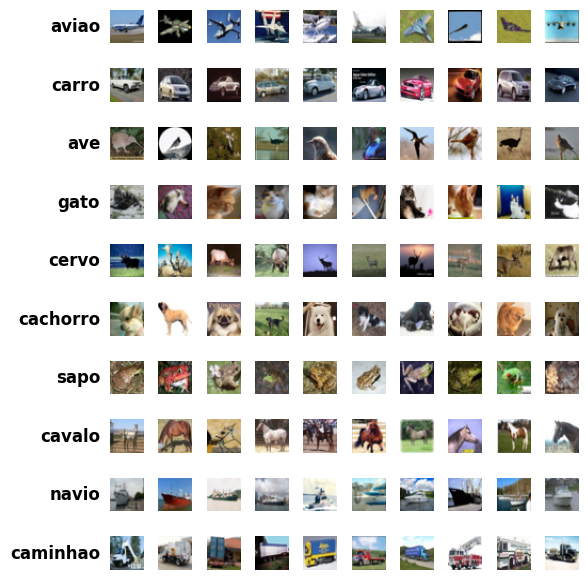

In [5]:
import matplotlib.pyplot as plt
import numpy as np

dataiter = iter(trainloader)
class_samples = {x: [] for x in range(0, 10)}
incomplete = [x for x in range(0, 10)]
while incomplete:
    images, labels = next(dataiter)
    for img, lbl in zip(images, labels):
        lbl = lbl.item()
        if lbl in incomplete:
            class_samples[lbl].append(img.numpy().transpose(1, 2, 0))
            if len(class_samples[lbl]) == 10:
                incomplete.remove(lbl)

def plot_class_grid(class_samples, classes):
    fig, axes = plt.subplots(10, 10, figsize=(6, 6))
    for i, class_name in enumerate(classes):
        samples = class_samples[i]
        for j in range(10):
            ax = axes[i, j]
            ax.axis('off')
            img = samples[j]
            ax.imshow(img)
            if j == 0:
                ax.text(-10, img.shape[0]//2, class_name, 
                        va='center', ha='right', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_class_grid(class_samples, classes)
